# Example Iterative Sense with regularization

In [46]:
import shutil
import torch
import tempfile
from pathlib import Path
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryPulseq
import numpy as np
import requests
import mrpro
import matplotlib.pyplot as plt

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
# Load data from Pulseq file using KTrajectoryPulseq
# Local path
h5_path = '/data/bouill01/conda_envs/mrpro/examples/20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds/pulseq_spiral_2D_220k0_128interleaves_golden_angle_vds_with_traj.h5'
seq_path = '/data/bouill01/conda_envs/mrpro/examples/20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds/20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds.seq'
kdatapuls = KData.from_file(h5_path, KTrajectoryPulseq(seq_path=seq_path))



In [47]:
# function to calculate Gaussian filter based on trajectory
def radius_filter(traj_kx, traj_ky, sigma):
    # Calculate the radius based on the k-space trajectory
    radius = np.sqrt(traj_kx**2 + traj_ky**2)
    
    # Normalize radius to the range [0, 1]
    radius_normalized = radius / np.max(radius)
    
    # Calculate the Gaussian filter based on the normalized radius
    filt_weights = np.exp(-(radius_normalized**2) / (2 * sigma**2))
    
    return filt_weights

In [48]:
from mrpro.data import KData, KTrajectory
from mrpro.data.traj_calculators import KTrajectoryPulseq
import matplotlib.pyplot as plt
import numpy as np

def shift_k_space_trajectory(kdatapuls):
    # Extract k-space trajectory from kdatapuls
    ky_pulseq = kdatapuls.traj.ky
    kx_pulseq = kdatapuls.traj.kx
    kz_pulseq = kdatapuls.traj.kz

    # Number of indices
    num_indices = ky_pulseq.shape[2]

    # Initialize lists to store shifted trajectories
    shifted_ky = ky_pulseq.clone()
    shifted_kx = kx_pulseq.clone()

    # Loop to apply the shift to each index
    for i in range(num_indices-1):
        # Calculate the shift for the current index
        shifted_ky[:,:,i,:] -= ky_pulseq[:,:,i,0]
        shifted_kx[:,:,i,:] -= kx_pulseq[:,:,i,0]

    # Create shifted KTrajectory object
    shifted_traj = KTrajectory(kx=shifted_kx, ky=shifted_ky, kz=kz_pulseq)
    # Create shifted KData object
    shifted_kdatapuls = KData(data=kdatapuls.data, traj=shifted_traj, header=kdatapuls.header)

    return shifted_kdatapuls

In [62]:
from mrpro import algorithms
shifted_kdatapuls = shift_k_space_trajectory(kdatapuls)

sigma = 0.1
shifted_kdatapuls = shift_k_space_trajectory(kdatapuls)
gauss_filter = radius_filter(shifted_kdatapuls.traj.kx.numpy(), shifted_kdatapuls.traj.ky.numpy(), sigma)

# Adjust the filter shape to match the k-space data shape
gauss_filter_expanded = gauss_filter[None  ,:,:] # Expand dimensions to match k-space data shape

print(f"Expanded Gaussian filter shape: {gauss_filter_expanded.shape}")
print(f"K-space data shape: {shifted_kdatapuls.data.shape}")

# Apply the filter to the k-space data
kspace_data_lowpass = shifted_kdatapuls.data * gauss_filter_expanded

kdata_lowpass = KData(
    data=kspace_data_lowpass,  
    traj=shifted_kdatapuls.traj, 
    header=shifted_kdatapuls.header 
)

# Perform the Direct reconstruction with the low-pass filtered k-space data
reconstruction_lowpass = algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_lowpass, noise=None, coil_combine=True)
x_0 = reconstruction_lowpass(kdata_lowpass).data

Expanded Gaussian filter shape: (1, 1, 1, 128, 220)
K-space data shape: torch.Size([1, 16, 1, 128, 220])


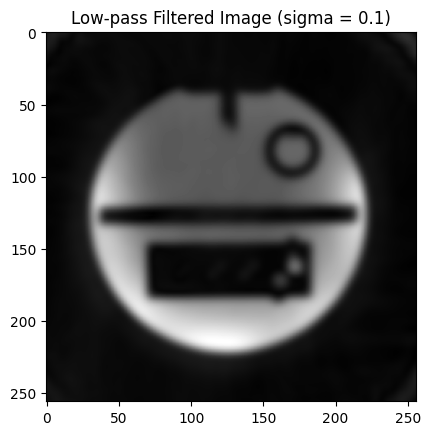

In [63]:
# Plot low-pass filtered image
plt.imshow(torch.abs(x_0[0, 0, 0, :, :]), cmap='gray')
plt.title(f'Low-pass Filtered Image (sigma = {sigma})')
plt.show()

In [65]:
iterative_sense_reconstruction = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(
    shifted_kdatapuls, n_max_iter=10, lambda_value=0.1, x0=x_0
)
img = iterative_sense_reconstruction(shifted_kdatapuls)

## Behind the scene

### Undersampling

In [52]:
# Define values to compare for us_idx
us_idx_values = torch.arange(0, 101, 3)[None, :]

### $x_{\text{true}}$

In [53]:
# x_true fully sampled
iterative_sense_reconstruction = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(shifted_kdatapuls, n_max_iter=4)
x_true = iterative_sense_reconstruction(shifted_kdatapuls)
x_true = x_true.data

### $y_{\text{true}} = {\text{kdatasimulated}}$

In [54]:
dcf_operator = mrpro.data.DcfData.from_traj_voronoi(shifted_kdatapuls.traj).as_operator()

# Define Fourier operator using the trajectory and header information in kdata
fourier_operator = mrpro.operators.FourierOp.from_kdata(shifted_kdatapuls)

img_coilwise = mrpro.data.IData.from_tensor_and_kheader(*fourier_operator.H(*dcf_operator(shifted_kdatapuls.data)), shifted_kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Create the acquisition operator A
acquisition_operator = fourier_operator @ csm_operator


# Unpack the tuple and perform the subtraction
kdata_simulated = acquisition_operator(x_true)

# Extract the k-space data from the tuple
kdata_simulated = kdata_simulated[0]    

# Create a KData object with the simulated k-space data
kdata_simulated_object = mrpro.data.KData(
    data=kdata_simulated,  
    traj=shifted_kdatapuls.traj, 
    header=shifted_kdatapuls.header 
)

# Split k-space data into other dimensions based on undersampling indices
kdata_simulated_object_us = KData.split_k1_into_other(kdata_simulated_object, us_idx_values , other_label='repetition')

### W

In [55]:
# Calculate dcf using the trajectory
dcf_operator = mrpro.data.DcfData.from_traj_voronoi(kdata_simulated_object_us.traj).as_operator()

### A

In [56]:
# Define Fourier operator using the trajectory and header information in kdata
fourier_operator = mrpro.operators.FourierOp.from_kdata(kdata_simulated_object_us)

# Calculate coil maps
# Note that operators return a tuple of tensors, so we need to unpack it,
# even though there is only one tensor returned from adjoint operator.
img_coilwise = mrpro.data.IData.from_tensor_and_kheader(*fourier_operator.H(*dcf_operator(kdata_simulated_object_us.data)), kdata_simulated_object_us.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Create the acquisition operator A
acquisition_operator = fourier_operator @ csm_operator

### $\lambda$

In [57]:
from mrpro.operators import LinearOperator

lamda = 0.1

# Create a custom lambda operator using AdjointLinearOperator
class LambdaOp(LinearOperator):
    def __init__(self, lamda):
        super().__init__()
        self.lamda = lamda

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor,]:
        return (self.lamda * x,)

    def adjoint(self, x: torch.Tensor) -> tuple[torch.Tensor,]:
        return (self.lamda * x,)

# Instantiate the lambda operator
lambda_operator = LambdaOp(lamda)

### $b = A^H W y - \lambda x_0 $

In [58]:
# Unpack the tuple and perform the subtraction
acquisition_operator_result = acquisition_operator.H(dcf_operator(kdata_simulated_object_us.data)[0])[0]

right_hand_side_low_res_filt= acquisition_operator_result + lamda * x_0_lowpass

### $H = A^H W A + \lambda$

In [59]:
cg_operator_low_res_filt = acquisition_operator.H @ dcf_operator @ acquisition_operator + lambda_operator

### Conjugate gradient minimisation

In [60]:
img_manual_low_res_filt = mrpro.algorithms.optimizers.cg(
    cg_operator_low_res_filt, right_hand_side_low_res_filt, initial_value=right_hand_side_low_res_filt, max_iterations=4
)

### Display

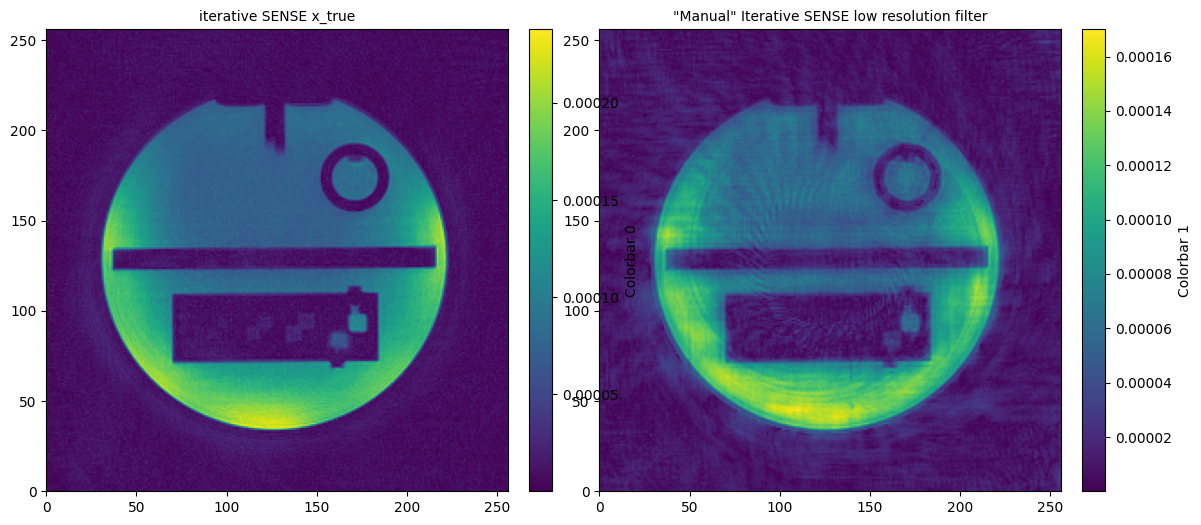

In [61]:
# Display the reconstructed image with colorbars
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # Increase the figure size
cbar_width = 0.05  # Width of the colorbar
spacing = 0.05  # Spacing between subplots

# Adjust left and right margins to accommodate the colorbars
plt.subplots_adjust(left=0.05, right=0.95, wspace=spacing, hspace=0.3)


im0 = ax[0].imshow(torch.abs(x_true[0, 0, 0, :, :]), extent=[0, x_true.shape[-1], 0, x_true.shape[-2]]) 
ax[0].set_title('iterative SENSE x_true', fontsize=10)
cbar0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.ax.set_ylabel('Colorbar 0')

im1 = ax[1].imshow(torch.abs(img_manual_low_res_filt[0, 0, 0, :, :]), extent=[0, img_manual_low_res_filt.shape[-1], 0, img_manual_low_res_filt.shape[-2]]) 
ax[1].set_title('"Manual" Iterative SENSE low resolution filter', fontsize=10)
cbar3 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
cbar3.ax.set_ylabel('Colorbar 1')

plt.show()